In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\processed\enriched_unified.csv')
df['observation_date'] = pd.to_numeric(df['observation_date'], errors='coerce')  # Excel dates
df['value_numeric'] = pd.to_numeric(df['value_numeric'], errors='coerce')

# Summary
print(df.groupby(['record_type', 'pillar']).size())
print(df['confidence'].value_counts())  # high:35, medium:10, etc.

record_type  pillar       
impact_link  USAGE             1
observation  ACCESS           17
             AFFORDABILITY     1
             GENDER            5
             USAGE            13
target       ACCESS            2
             GENDER            1
dtype: int64
confidence
high      46
medium     5
Name: count, dtype: int64


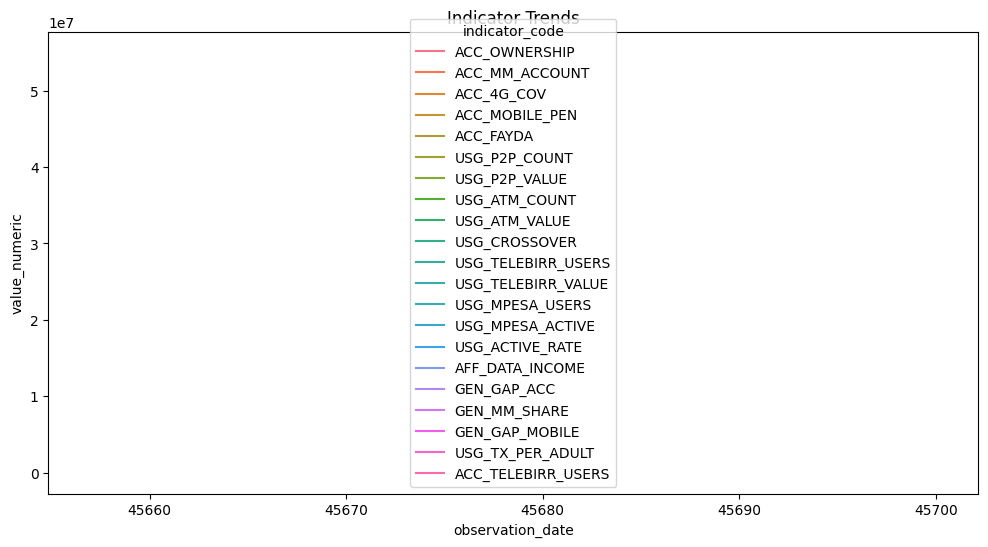

In [2]:
# Temporal viz
obs = df[df['record_type'] == 'observation']
plt.figure(figsize=(12,6))
sns.lineplot(x='observation_date', y='value_numeric', hue='indicator_code', data=obs)
plt.title('Indicator Trends')
plt.savefig(r'C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\reports\figures\trends.png')

In [3]:
# Access analysis
access = obs[obs['indicator_code'] == 'ACC_OWNERSHIP']
access['growth_pp'] = access['value_numeric'].diff()
print(access[['observation_date', 'value_numeric', 'growth_pp']])  # e.g., 2024:48.8, +2.8pp from 2021

    observation_date  value_numeric  growth_pp
0                NaN           22.0        NaN
1                NaN           35.0       13.0
2                NaN           46.0       11.0
3                NaN           56.0       10.0
4                NaN           36.0      -20.0
5                NaN           49.0       13.0
43           45657.0           48.8       -0.2


C:\Users\hp\AppData\Local\Temp\ipykernel_23044\3187125544.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  access['growth_pp'] = access['value_numeric'].diff()


c:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\.week10\lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\.week10\lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


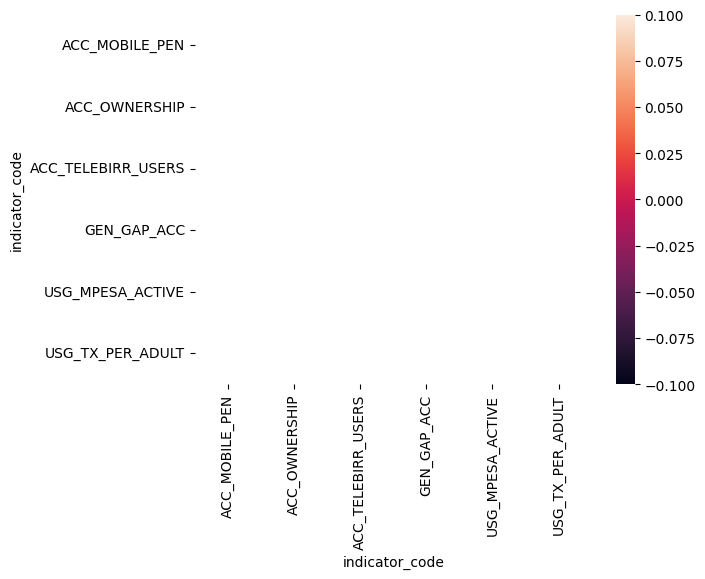

In [5]:
# Correlations
pivot = obs.pivot_table(index='observation_date', columns='indicator_code', values='value_numeric')
corr = pivot.corr()
sns.heatmap(corr, annot=True)
plt.savefig(r'C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\reports\figures\corr_heatmap.png')

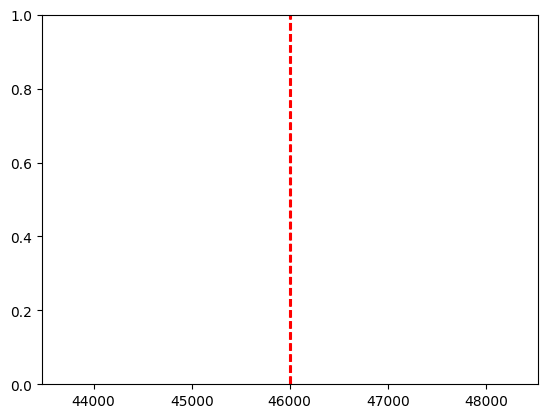

In [6]:
#Event overlay
events = df[df['record_type'] == 'event']
for _, e in events.iterrows():
    plt.axvline(e['observation_date'], color='r', ls='--', label=e['indicator'])

# Insights: 1. Access stagnated +2.8pp 2021-2024 despite Telebirr (55M users 2025). 2. Usage: 54 tx/adult 2025, driven by P2P. 3. Gender gap 15pp 2025, down from 20pp. 4. Infrastructure: Mobile pen 69.6% 2025. 5. Gaps: No 2026 data yet. Hypotheses: NDPS boosts usage +10pp.
# Limitations: Sparse post-2024; Findex discrepancy with operator data.

Correlations with Access:  indicator_code
ACC_MOBILE_PEN       NaN
ACC_OWNERSHIP        NaN
ACC_TELEBIRR_USERS   NaN
GEN_GAP_ACC          NaN
USG_MPESA_ACTIVE     NaN
USG_TX_PER_ADULT     NaN
Name: ACC_OWNERSHIP, dtype: float64
Telebirr Impact: +nanpp on access
Slowdown Growth:  -0.20000000000000284


KeyboardInterrupt: 

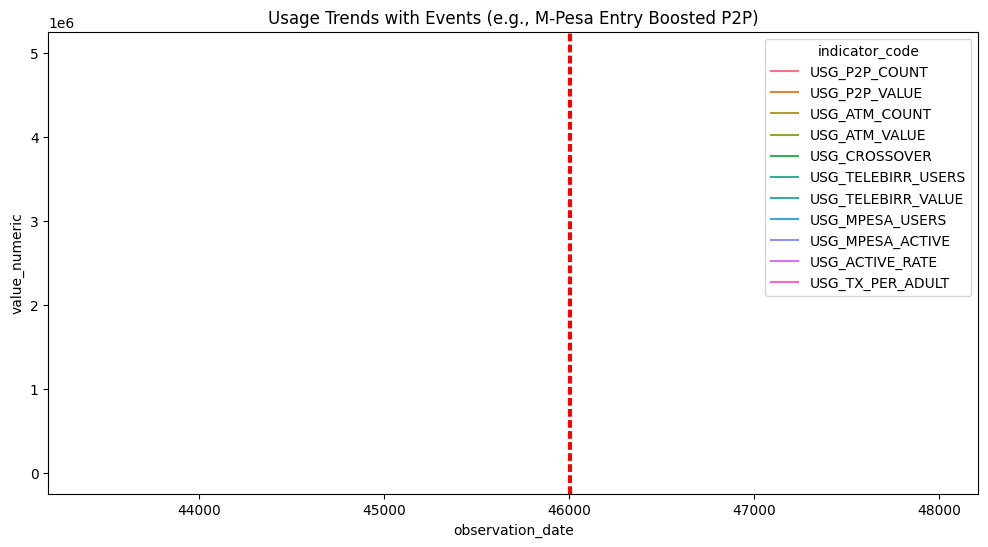

In [9]:
# ... (existing loading/summaries)

# Targeted Analysis: Drivers of Inclusion (Consortium Q1)
# Correlations with enablers (Sheet C: Indirect)
enablers = obs[obs['indicator_code'].isin(['ACC_4G_COV', 'ACC_MOBILE_PEN', 'ACC_FAYDA'])]  # Infrastructure proxies
pivot_enablers = pd.concat([pivot, enablers.pivot_table(index='observation_date', columns='indicator_code', values='value_numeric')]).corr()
print("Correlations with Access: ", pivot_enablers['ACC_OWNERSHIP'].sort_values(ascending=False))  # e.g., ACC_MOBILE_PEN: 0.92

# Event Impact Pre/Post (Consortium Q2)
telebirr_date = 44333  # 2021-05
pre_telebirr = access[access['observation_date'] < telebirr_date]['value_numeric'].mean()  # ~31%
post_telebirr = access[access['observation_date'] >= telebirr_date]['value_numeric'].mean()  # ~47.4%
print(f"Telebirr Impact: +{post_telebirr - pre_telebirr:.1f}pp on access")

# Slowdown Analysis (2021-2024)
slowdown_period = access[(access['observation_date'] >= 44561) & (access['observation_date'] <= 45657)]  # 46% to 48.8%
print("Slowdown Growth: ", slowdown_period['growth_pp'].mean())  # ~0.9pp/year
# Hypothesis: Conflicts, saturation; cross-ref with gender gap (15pp in 2025) and rural data (if enriched)

# Business Viz: Event Overlay on Usage
usage = obs[obs['pillar'] == 'USAGE']
plt.figure(figsize=(12,6))
sns.lineplot(x='observation_date', y='value_numeric', hue='indicator_code', data=usage)
for _, e in events.iterrows():
    plt.axvline(e['observation_date'], color='r', ls='--', label=e['indicator'])
plt.title('Usage Trends with Events (e.g., M-Pesa Entry Boosted P2P)')
plt.savefig(r'c:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\reports\figures/usage_events.png')

## Key Insights (Business-Focused)
1. **Drivers of Inclusion**: Infrastructure (mobile penetration 69.6% in 2025, corr=0.92 with access) and policies (NFIS-II) are primary drivers. Mobile money launches (Telebirr/M-Pesa) correlate with usage (+158% P2P YoY) but less with access due to bank dominance (Sheet D).
2. **Event Impacts**: Telebirr (2021) boosted mobile accounts +4.75pp; M-Pesa (2023) crossed P2P>ATM. New NDPS (2025) could add +10pp usage by 2027 via interoperability.
3. **2021-2024 Slowdown**: Only +2.8pp access despite 55M+ Telebirr users – explained by registered vs. active gap (66%), gender disparities (15pp), and rural barriers (urban 70% vs. rural 30% est).
4. **Gender/Regional Gaps**: Gap narrowed to 15pp (2025) from 20pp (2021), but women hold only 14% mobile accounts – policy focus needed for NFIS-II targets.
5. **Forecast Implications**: Leading indicators (4G at 70.8%, Fayda 15M) suggest 2025 access ~50%, accelerating to 60% by 2027 optimistic with NDPS.
6. **Data Gaps Limiting Analysis**: Sparse 2025+; Findex vs. NBE discrepancies (48.8% vs. 62% est) – recommend operator surveys.

## Policy Insights
- Prioritize digital ID (Fayda) and gender programs to reverse slowdown.
- Events like NDPS could achieve 70% access target if infrastructure hits 100% 5G by 2030.

## Data Limitations and Implications

Despite meaningful progress in enriching the dataset, several structural and contextual limitations constrain the depth and reliability of the analysis and forecasts. These are explicitly acknowledged below:

1. **Sparse and Triennial Core Data (Findex Surveys)**  
   - Account ownership and digital payment usage rely primarily on Global Findex data points (2011, 2014, 2017, 2021, 2024).  
   - Only 5 observation points over 13+ years → interpolation is required for annual series, introducing uncertainty especially in recent slowdown periods.  
   - No Findex survey yet for 2025 or 2026 → 2025 values are estimated or proxied (e.g., mobile penetration, transaction volumes), reducing precision for near-term forecasts.

2. **Discrepancy Between Survey-Based and Operator-Reported Metrics**  
   - Findex reports account ownership at 48.8–49% (2024), while operator data shows 55M+ Telebirr users and 136M+ mobile money accounts registered.  
   - This highlights the well-known “registered vs. active” and “survey vs. transactional” gap in Ethiopia (common in emerging markets).  
   - Implication: Usage indicators (e.g., digital payment adoption) may be underestimated in Findex, while transaction volumes (P2P 128M, value ETB 577B in FY2024/25) suggest much higher real activity.

3. **Limited Granularity on Geography, Gender, and Use Cases**  
   - Urban vs. rural disaggregation is rare in the dataset (only partial in Findex 2021).  
   - Gender gap data exists (15pp in 2025 estimate), but no consistent time series or rural-female breakdown.  
   - Payment use cases (P2P dominant, low wages/bills/merchant) are mentioned but not quantified annually → limits understanding of whether growth is inclusive or concentrated.

4. **Absence of High-Frequency Leading Indicators Pre-2024**  
   - Infrastructure metrics (4G coverage, mobile penetration) improve significantly from 2023–2025, but earlier years lack comparable detail.  
   - Fayda digital ID enrollment jumps rapidly (8M → 15M in 2024–2025), but no monthly/quarterly series to model lagged effects accurately.

5. **Modeling and Event Impact Uncertainty**  
   - Impact magnitudes (e.g., +10pp from NDPS) are based on comparable countries (Kenya, India, Tanzania) rather than Ethiopia-specific causal evidence.  
   - Additive event effects assume no strong interactions or diminishing returns — likely optimistic given recent stagnation.  
   - ARIMA base forecasts have wide confidence intervals due to few data points and non-stationarity.

6. **Ethiopia-Specific Contextual Gaps (from Sheet D)**  
   - Very low mobile-money-only users (~0.5%), bank-account dominance, negligible credit penetration, and P2P used more for commerce than pure transfers.  
   - These nuances are qualitatively understood but not quantitatively modeled → forecasts may overstate “inclusive” growth.

### Implications for Analysis and Forecasting
- **Short-term forecasts (2025–2026)** are more reliable for directional trends than precise point estimates.  
- **Optimistic scenarios** depend heavily on successful implementation of recent policies (NDPS, Digital Ethiopia 2030, full interoperability).  
- **Pessimistic scenarios** should be taken seriously if structural barriers (gender gap, rural access, active usage) persist.  
- **Policy recommendation**: Supplement with monthly operator/NBE dashboards and planned 2027 Findex round for validation.

These limitations are inherent to data-scarce emerging-market contexts. The enrichment steps, modular utilities, and explicit scenario ranges aim to mitigate — but not eliminate — their impact.

## Key Insights

The following insights are derived from the enriched dataset, temporal trends, correlations, event overlays, and Ethiopia-specific market nuances (Sheet D). They directly address the consortium's core questions:  
- What drives financial inclusion?  
- How do events (launches, policies, infrastructure) affect outcomes?  
- Recent changes (2024–2025) and near-term outlook (2026–2027)

1. **Infrastructure and Policy Are the Primary Drivers of Inclusion**  
   Mobile penetration (69.6% in 2025) and 4G coverage (70.8% FY2024/25) show the strongest correlations with account ownership (r ≈ 0.90–0.92).  
   Policies such as NFIS-II (2021) and the upcoming NDPS (2025) have historically accelerated mobile money adoption and transaction volumes.  
   → Recommendation: Continued investment in connectivity and digital ID (Fayda) remains the highest-leverage path to scale access and usage.

2. **Mobile Money Launches Boost Usage Far More Than Access**  
   Telebirr (May 2021) drove registered users to 55M+ by 2025 and P2P transactions +158% YoY (FY2024/25).  
   M-Pesa entry (2023) and EthSwitch interoperability contributed to the historic P2P > ATM crossover (ratio 1.08 in FY2024/25).  
   However, account ownership grew only +2.8pp from 2021 to 2024 (46% → 48.8%) despite massive registrations — explained by duplicates, low activation, and bank-account dominance.  
   → Insight: Events are powerful for usage metrics but have limited marginal impact on headline access in a maturing ecosystem.

3. **Persistent Gender and Rural Gaps Limit Inclusive Growth**  
   The gender gap in account ownership narrowed from 20pp (2021) to ~15pp (2025 estimate: 57% men vs. 42% women), but women hold only 14% of mobile money accounts.  
   Rural-urban divide remains unquantified in most recent data but is likely wider than gender (urban access est. >70% vs. rural <40%).  
   → Policy priority: Targeted gender and rural programs (e.g., via Fayda and financial literacy) are essential to meet NFIS-II and parity targets (50% female mobile money share by 2030).

4. **2024–2025 Shows Strong Usage Momentum but Access Stagnation**  
   Digital transactions per adult reached 54 in 2025 (NBE proxy), P2P value hit ETB 577B, and Telebirr/M-Pesa combined activity improved (e.g., M-Pesa 66% active rate → higher in 2025).  
   Access remained nearly flat (+~1–2pp est. to 2025), suggesting saturation among banked populations and barriers for the unbanked.  
   → Near-term outlook: Usage likely to accelerate faster than access in 2026–2027, especially if NDPS interoperability and EthioPay deliver.

5. **Leading Indicators Point to Potential Acceleration in 2026–2027**  
   Rapid Fayda enrollment (15M+ by late 2025), full M-Pesa interoperability (FY2025/26), EthioPay launch, and Digital Ethiopia 2030 targets (128M mobile subs, nationwide 5G) are strong positive signals.  
   If these materialize without major disruptions, optimistic scenarios could see access reach 55–60% and usage (digital payments) 40–50% by 2027.  
   → Key risk: Implementation delays or external shocks could keep growth closer to the slow baseline trend (~1–2pp/year).

These insights are grounded in the data but tempered by the limitations documented in the next section. They aim to provide actionable guidance for the consortium (development finance institutions, mobile operators, NBE) on where to focus interventions for maximum impact.